
# Lab 11: Simulations


We will go over [iteration](https://www.inferentialthinking.com/chapters/09/2/Iteration.html) and [simulations](https://www.inferentialthinking.com/chapters/09/3/Simulation.html), as well as introduce the concept of [randomness](https://www.inferentialthinking.com/chapters/09/Randomness.html).

The data used in this lab will contain salary data and other statistics for basketball players from the 2014-2015 NBA season. This data was collected from the following sports analytic sites: [Basketball Reference](http://www.basketball-reference.com) and [Spotrac](http://www.spotrac.com).

In [1]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc
!pip install datascience

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [2]:
# Connect Google Drive to Colab so you can access your files
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/')

Mounted at /content/drive


In [3]:
# Run this cell, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

## 1. Nachos and Conditionals

In Python, the boolean is a data type with only two possible values:  `True` and `False`. Expressions containing comparison operators such as `<` (less than), `>` (greater than), and `==` (equal to) evaluate to Boolean values. A list of common comparison operators can be found below!

<img src="https://github.com/data-8/materials-sp24/blob/main/lab/lab05/comparisons.png?raw=1" alt="Chart of comparison operators">

Run the cell below to see an example of a comparison operator in action.

In [4]:
3 > (1 + 1)

True

We can even assign the result of a comparison operation to a variable. Note that `==` and `=` are **not** the same!

In [5]:
result = 10 / 2 == 5
result

True

Just like arithmetic operators can be applied on every item of an array, comparison operators can also be used on arrays to compare an entire array with some value. The output of this comparison is an array of boolean values.

In [6]:
make_array(1, 5, 7, 8, 3, -1) > 3

array([False,  True,  True,  True, False, False], dtype=bool)

One day, when you come home after a long week, you see a hot bowl of nachos waiting on the dining table! Let's say that whenever you take a nacho from the bowl, it will either have only **cheese**, only **salsa**, **both** cheese and salsa, or **neither** cheese nor salsa (a sad tortilla chip indeed).

Let's try and simulate taking nachos from the bowl at random using the function, `np.random.choice(...)`.

### `np.random.choice`

`np.random.choice` picks one item at random from the given array. It is equally likely to pick any of the items. Run the cell below several times, and observe how the results change. _Tip:_ To keep running a cell multiple times you can use the keyboard shortcut `ctrl` + `return`.

In [7]:
nachos = make_array('cheese', 'salsa', 'both', 'neither')
np.random.choice(nachos)

'salsa'

To repeat this process multiple times, pass in an int `n` as the second argument to return `n` different random choices. By default, `np.random.choice` samples **with replacement** and returns an *array* of items. Sampling **with replacement** means that after an element is drawn, it is replaced back to where you are sampling from and can be drawn again in the future. If we sample `n` times with replacement, each time, every element has an equal chance of being selected.

Run the next cell to see an example of sampling with replacement 10 times from the `nachos` array.

In [8]:
np.random.choice(nachos, 10)

array(['salsa', 'salsa', 'salsa', 'neither', 'neither', 'neither',
       'neither', 'salsa', 'both', 'salsa'],
      dtype='<U7')

To count the number of times a certain type of nacho is randomly chosen, we can use `np.count_nonzero`

### `np.count_nonzero`

`np.count_nonzero` counts the number of non-zero values that appear in an array. When an array of boolean values are passed through the function, it will count the number of `True` values (remember that in Python, **`True` is coded as 1 and `False` is coded as 0.**)

Run the next cell to see an example that uses `np.count_nonzero`.

In [9]:
np.count_nonzero(make_array(True, False, False, True, True))

3

**Question 1.1** Assume we took ten nachos at random, and stored the results in an array called `ten_nachos` as done below. **Find the number of nachos with only cheese using code** (do not manually enter the final answer).  

*Hint:* Our solution involves a comparison operator (e.g. `==`, `<`, ...) and the `np.count_nonzero` method.


In [11]:
ten_nachos = make_array('neither', 'cheese', 'both', 'both', 'cheese', 'salsa', 'both', 'neither', 'cheese', 'both')
number_cheese = np.count_nonzero(ten_nachos == 'cheese')
number_cheese

3

**Conditional Statements**

A conditional statement is a multi-line statement that allows Python to choose among different alternatives based on the truth value of an expression.

Here is a basic example.

```python
def sign(x):
    if x > 0:
        return 'Positive'
    else:
        return 'Negative'
```

If the input `x` is greater than `0`, we return the string `'Positive'`. Otherwise, we return `'Negative'`.

If we want to test multiple conditions at once, we use the following general format.

```python
if <if expression>:
    <if body>
elif <elif expression 0>:
    <elif body 0>
elif <elif expression 1>:
    <elif body 1>
...
else:
    <else body>
```

Only the body for the first conditional expression that is true will be evaluated. Each `if` and `elif` expression is evaluated and considered in order, starting at the top. `elif` can only be used if an `if` clause precedes it. As soon as a true value is found, the corresponding body is executed, and the rest of the conditional statement is skipped. If none of the `if` or `elif` expressions are true, then the `else body` is executed.

For more examples and explanation, refer to the section on conditional statements [here](https://inferentialthinking.com/chapters/09/1/Conditional_Statements.html).

**Question 1.2** Complete the following conditional statement so that the string `'More please'` is assigned to the variable `say_please` if the number of nachos with cheese in `ten_nachos` is less than `5`. Use the if statement to do this (do not directly reassign the variable `say_please`).

*Hint*: You should be using `number_cheese` from Question 1.


In [13]:
say_please = '?'

if number_cheese < 5:
    say_please = 'More please'
say_please

'More please'

**Question 1.3** Write a function called `nacho_reaction` that returns a reaction (as a string) based on the type of nacho passed in as an argument. Use the table below to match the nacho type to the appropriate reaction.

|Nacho Type|Reaction|
|---|---|
|cheese|Cheesy!|
|salsa|Spicy!|
|both|Wow!|
|neither|Meh.|

*Hint:* If you're failing the test, double check the spelling of your reactions.


In [15]:
def nacho_reaction(nacho):
    if nacho == "cheese":
        return 'Cheesy!'
    elif nacho == "salsa":
        return 'Spicy!'
    elif nacho == "both":
        return 'Wow!'
    else:
        return 'Meh.'

spicy_nacho = nacho_reaction('salsa')
spicy_nacho

'Spicy!'

**Question 1.4** Create a table `ten_nachos_reactions` that consists of the nachos in `ten_nachos` as well as the reactions for each of those nachos. The columns should be called `Nachos` and `Reactions`.

*Hint:* Consider using the `apply` method, which returns an array.


In [16]:
ten_nachos_tbl = Table().with_column('Nachos', ten_nachos)
ten_nachos_reactions = ten_nachos_tbl.with_column('Reactions', ten_nachos_tbl.apply(nacho_reaction, 'Nachos'))
ten_nachos_reactions

Nachos,Reactions
neither,Meh.
cheese,Cheesy!
both,Wow!
both,Wow!
cheese,Cheesy!
salsa,Spicy!
both,Wow!
neither,Meh.
cheese,Cheesy!
both,Wow!


**Question 1.5** Using code, find the number of 'Wow!' reactions for the nachos in `ten_nachos_reactions`.


In [18]:
number_wow_reactions = np.count_nonzero(ten_nachos_reactions.column('Reactions') == 'Wow!')
number_wow_reactions

4

## 2. Simulations and For Loops
Using a `for` statement, we can perform a task multiple times. This is known as iteration. The general structure of a for loop is:

`for <placeholder> in <array>:` followed by indented lines of code that are repeated for each element of the `array` being iterated over. You can read more about for loops [here](https://www.inferentialthinking.com/chapters/09/2/Iteration.html).

**NOTE:** We often use `i` as the `placeholder` in our class examples, but you could name it anything! Some examples can be found below.

One use of iteration is to loop through a set of values. For instance, we can print out all of the colors of the rainbow.

In [19]:
rainbow = make_array("red", "orange", "yellow", "green", "blue", "indigo", "violet")

for color in rainbow:
    print(color)

red
orange
yellow
green
blue
indigo
violet


We can see that the indented part of the `for` loop, known as the body, is executed once for each item in `rainbow`. The name `color` is assigned to the next value in `rainbow` at the start of each iteration. Note that the name `color` is arbitrary; we could easily have named it something else. Whichever name we pick, we need to use it consistently throughout the `for` loop.

In [20]:
for another_name in rainbow:
    print(another_name)

red
orange
yellow
green
blue
indigo
violet


In general, however, we would like the variable name to be somewhat informative.

**Question 2.1** In the following cell, we've loaded the text of _Pride and Prejudice_ by Jane Austen, split it into individual words, and stored these words in an array `p_and_p_words`. Using a `for` loop, assign `longer_than_five` to the number of words in the novel that are more than 5 letters long.

*Hint*: You can find the number of letters in a word with the `len` function.

*Hint*: How can you use `longer_than_five` to keep track of the number of words that are more than five letters long?


In [22]:
austen_string = open('./DS/Austen_PrideAndPrejudice.txt', encoding='utf-8').read()
p_and_p_words = np.array(austen_string.split())

longer_than_five = 0

for a in p_and_p_words:
    if len(a) > 5:
        longer_than_five += 1
longer_than_five

35453

Another way we can use `for` loops is to repeat lines of code many times. Recall the structure of a `for` loop:

`for <placeholder> in <array>:` followed by indented lines of code that are repeated for each element of the array being iterated over.

Sometimes, we don't care about what the value of the placeholder is. We instead take advantage of the fact that the `for` loop will repeat as many times as the length of our array. In the following cell, we iterate through an array of length 5 and print out "Hello, world!" in each iteration, but we don't need to use the placeholder `i` in the body of our `for` loop.

In [24]:
for i in np.arange(5):
    print("Hello, world!")

Hello, world!
Hello, world!
Hello, world!
Hello, world!
Hello, world!


**Question 2.2** Using a simulation with 10,000 trials, assign `num_different` to the **number** of times, in 10,000 trials, that two words picked uniformly at random (with replacement) from Pride and Prejudice have different lengths.

*Hint 1*: What function did we use in section 1 to sample at random with replacement from an array?

*Hint 2*: Remember that `!=` checks for non-equality between two items.


In [31]:
trials = 10000
num_different = 0

for _ in np.arange(trials):
    word1 = np.random.choice(p_and_p_words)
    word2 = np.random.choice(p_and_p_words)
    if len(word1) != len(word2):
        num_different += 1
num_different

8568

## 3. Sampling Basketball Data

We will now introduce the topic of sampling, which we’ll be discussing in more depth in this week’s lectures. We’ll guide you through this code, but if you wish to read more about different kinds of samples before attempting this question, you can check out [section 10 of the textbook](https://www.inferentialthinking.com/chapters/10/Sampling_and_Empirical_Distributions.html).

Run the cell below to load player and salary data that we will use for our sampling.

In [32]:
player_data = Table().read_table("./DS/player_data.csv")
salary_data = Table().read_table("./DS/salary_data.csv")
full_data = salary_data.join("PlayerName", player_data, "Name")

# The show method immediately displays the contents of a table.
# This way, we can display the top of two tables using a single cell.
player_data.show(3)
salary_data.show(3)
full_data.show(3)

Name,Age,Team,Games,Rebounds,Assists,Steals,Blocks,Turnovers,Points
James Harden,25,HOU,81,459,565,154,60,321,2217
Chris Paul,29,LAC,82,376,838,156,15,190,1564
Stephen Curry,26,GSW,80,341,619,163,16,249,1900


PlayerName,Salary
Kobe Bryant,23500000
Amar'e Stoudemire,23410988
Joe Johnson,23180790


PlayerName,Salary,Age,Team,Games,Rebounds,Assists,Steals,Blocks,Turnovers,Points
A.J. Price,62552,28,TOT,26,32,46,7,0,14,133
Aaron Brooks,1145685,30,CHI,82,166,261,54,15,157,954
Aaron Gordon,3992040,19,ORL,47,169,33,21,22,38,243


Rather than getting data on every player (as in the tables loaded above), imagine that we had gotten data on only a smaller subset of the players. For 492 players, it's not so unreasonable to expect to see all the data, but usually we aren't so lucky.

If we want to make estimates about a certain numerical property of the population, we may have to come up with these estimates based only on a smaller sample. The numerical property of the population is known as a **parameter**, and the estimate is known as a **statistic** (e.g. the mean or median). Whether these estimates are useful or not often depends on how the sample was gathered. We have prepared some example sample datasets to see how they compare to the full NBA dataset. Later we'll ask you to create your own samples to see how they behave.

To save typing and increase the clarity of your code, we will package the analysis code into a few functions. This will be useful in the rest of the lab as we will repeatedly need to create histograms and collect summary statistics from that data.

We've defined the `histograms` function below, which takes a table with columns `Age` and `Salary` and draws a histogram for each one. It uses bin widths of 1 year for `Age` and $1,000,000 for `Salary`.

Two histograms should be displayed below


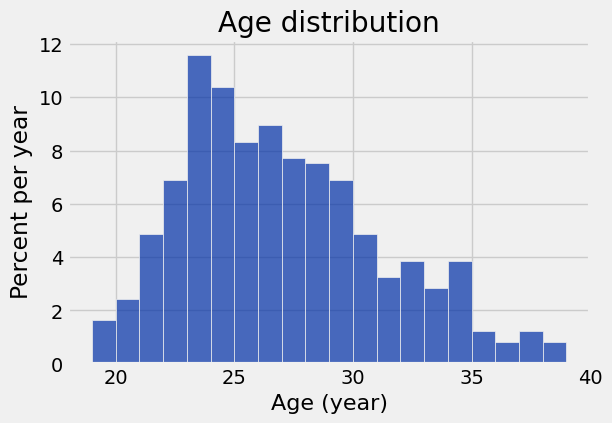

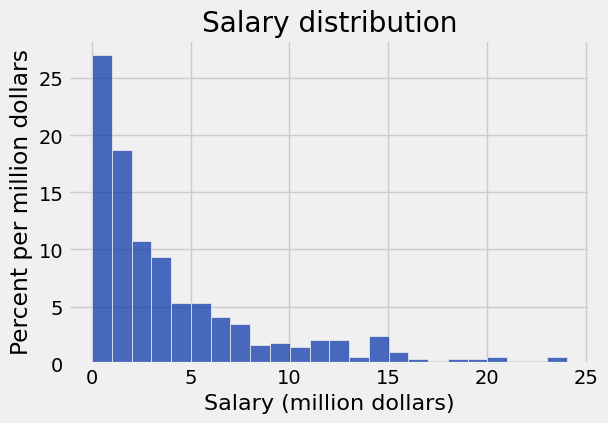

In [33]:
def histograms(t):
    ages = t.column('Age')
    salaries = t.column('Salary')/1000000
    t1 = t.drop('Salary').with_column('Salary', salaries)
    age_bins = np.arange(min(ages), max(ages) + 2, 1)
    salary_bins = np.arange(min(salaries), max(salaries) + 1, 1)
    t1.hist('Age', bins=age_bins, unit='year')
    plt.title('Age distribution')
    t1.hist('Salary', bins=salary_bins, unit='million dollars')
    plt.title('Salary distribution')

histograms(full_data)
print('Two histograms should be displayed below')

**Question 3.1**. Create a function called `compute_statistics` that takes a table containing an "Age" column and a "Salary" column and:
- Draws a histogram of ages
- Draws a histogram of salaries
- Returns a two-element array containing the average age and average salary (in that order)

You can call the `histograms` function to draw the histograms!


array([  2.65365854e+01,   4.26977577e+06])

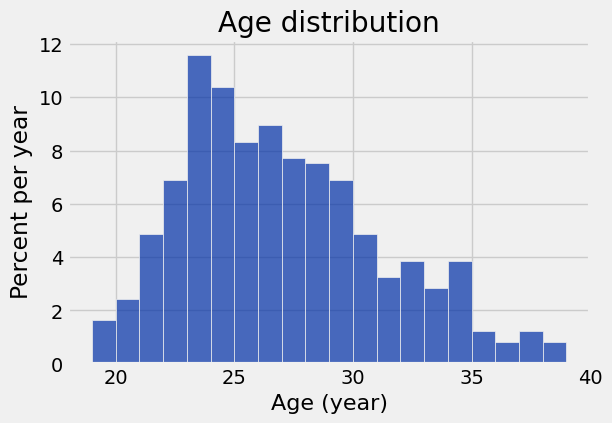

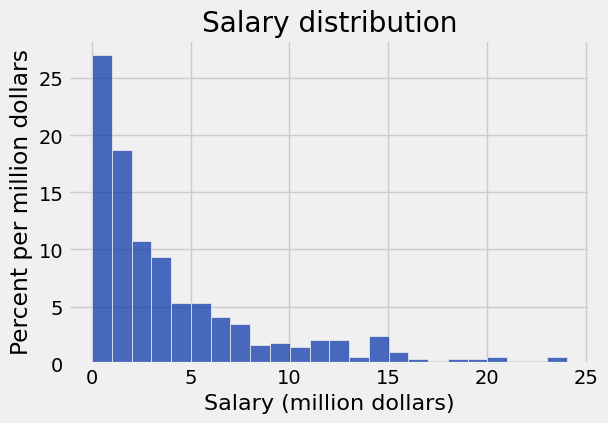

In [35]:
def compute_statistics(age_and_salary_data):
    histograms(age_and_salary_data)
    age = np.mean(age_and_salary_data.column('Age'))
    salary = np.mean(age_and_salary_data.column('Salary'))
    return make_array(age, salary)


full_stats = compute_statistics(full_data)
full_stats

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a pdf file for you to submit. **Please save before exporting!**

In [36]:
# should change the directory and file name matching to yours
!jupyter nbconvert './DS/lab11(SSU).ipynb' --to pdf

[NbConvertApp] Converting notebook ./DS/lab11(SSU).ipynb to pdf
[NbConvertApp] Support files will be in lab11(SSU)_files/
[NbConvertApp] Making directory ./lab11(SSU)_files
[NbConvertApp] Writing 87915 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 174299 bytes to DS/lab11(SSU).pdf
